In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility (optional)
torch.manual_seed(0)

# MNIST normalization constants and helpers
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081
MIN_NORM = (0.0 - MNIST_MEAN) / MNIST_STD
MAX_NORM = (1.0 - MNIST_MEAN) / MNIST_STD



In [2]:
import torch
import sys
import os

# Add the parent directory to sys.path so 'diff' can be imported
sys.path.append('/Users/lorantnagy/Documents/CODE/DIFFUSION/cleanfake/')

from diff.sde import Langevin
from diff.sim_core import SDESolver
from diff.integrator import EulerMaruyama

In [3]:
def denormalize(x):
    # x in normalized coords -> [0,1]
    return torch.clamp(x * MNIST_STD + MNIST_MEAN, 0.0, 1.0)

class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x); x = F.relu(x)
        x = self.conv2(x); x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x); x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        # Return log-probabilities
        return F.log_softmax(x, dim=1)

def get_seven_probability(model, x, device, normalize=True):
    model.eval()
    with torch.no_grad():
        if len(x.shape) == 2:
            x = x.unsqueeze(0).unsqueeze(0)
        elif len(x.shape) == 3:
            x = x.unsqueeze(0)
        x = x.to(device)
        if normalize:
            x = (x - MNIST_MEAN) / MNIST_STD
        log_probs = model(x)           # log p(y|x)
        probs = log_probs.exp()        # p(y|x)
        return probs[0, 7].item()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:

# print(f"Using device: {device}")

# # Download data
# print("Downloading MNIST dataset...")
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
# ])
# train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
# test_dataset  = datasets.MNIST('./data', train=False, transform=transform)

# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)

# # Initialize model
# model = MNISTNet().to(device)

# # Train model
# print("Training model...")
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# model.train()
# for epoch in range(3):
#     for batch_idx, (data, target) in enumerate(train_loader):
#         data, target = data.to(device), target.to(device)
#         optimizer.zero_grad()
#         log_probs = model(data)              # log p
#         loss = F.nll_loss(log_probs, target)
#         loss.backward()
#         optimizer.step()
#         if batch_idx % 100 == 0:
#             print(f'Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}')

# torch.save(model.state_dict(), 'mnist_model.pth')
# print("Model training complete and saved!")



In [5]:
# load saved model
model = MNISTNet().to(device)
model.load_state_dict(torch.load('mnist_model.pth', map_location=device))

<All keys matched successfully>

In [6]:

print("\nTesting on real MNIST samples...")
test_dataset_no_transform = datasets.MNIST('./data', train=False, transform=transforms.ToTensor())
for i in range(20):
    img, label = test_dataset_no_transform[i]
    prob = get_seven_probability(model, img, device, normalize=True)
    print(f"Image {i} (label={label}): P(7) = {prob:.4f}")



Testing on real MNIST samples...
Image 0 (label=7): P(7) = 1.0000
Image 1 (label=2): P(7) = 0.0000
Image 2 (label=1): P(7) = 0.0000
Image 3 (label=0): P(7) = 0.0000
Image 4 (label=4): P(7) = 0.0000
Image 5 (label=1): P(7) = 0.0000
Image 6 (label=4): P(7) = 0.0000
Image 7 (label=9): P(7) = 0.0000
Image 8 (label=5): P(7) = 0.0000
Image 9 (label=9): P(7) = 0.0000
Image 10 (label=0): P(7) = 0.0000
Image 11 (label=6): P(7) = 0.0000
Image 12 (label=9): P(7) = 0.0000
Image 13 (label=0): P(7) = 0.0000
Image 14 (label=1): P(7) = 0.0000
Image 15 (label=5): P(7) = 0.0000
Image 16 (label=9): P(7) = 0.0002
Image 17 (label=7): P(7) = 1.0000
Image 18 (label=3): P(7) = 0.0035
Image 19 (label=4): P(7) = 0.0000


In [44]:


# MNIST constants
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTNet().to(device)
model.load_state_dict(torch.load('mnist_model.pth'))
model.eval()

target_class = 7
dim = 28 * 28

def grad_U__1minusG(x):
    """
    Gradient of U(x) = 1 - p(y=target_class | x)
    
    Args:
        x: flattened normalized image tensor, shape [batch_size, dim]
    
    Returns:
        ∇U(x) = -∇p(y=target_class | x), shape [batch_size, dim]
    """
    batch_size = x.shape[0]
    
    # Enable gradients and set model to eval mode
    with torch.enable_grad():
        model.eval()  # Ensure eval mode
        x_img = x.view(batch_size, 1, 28, 28).detach().clone().requires_grad_(True)
        
        log_probs = model(x_img)
        probs = torch.exp(log_probs)
        p_target = probs[:, target_class]
        
        grad_img = torch.autograd.grad(
            p_target, 
            x_img, 
            grad_outputs=torch.ones_like(p_target),
            retain_graph=False,
            create_graph=False
        )[0]
    
    # Detach to break gradient tracking
    return -grad_img.detach().view(batch_size, -1)

# def grad_U_logprob(x):
#     """
#     Gradient of U(x) = -log p(y=target_class | x)
    
#     Args:
#         x: flattened normalized image tensor, shape [batch_size, dim]
    
#     Returns:
#         ∇U(x) = -∇log p(y=target_class | x), shape [batch_size, dim]
#     """
#     batch_size = x.shape[0]
    
#     # Enable gradients and set model to eval mode
#     with torch.enable_grad():
#         model.eval()
#         x_img = x.view(batch_size, 1, 28, 28).detach().clone().requires_grad_(True)
        
#         log_probs = model(x_img)
#         log_p_target = log_probs[:, target_class]
        
#         grad_img = torch.autograd.grad(
#             log_p_target, 
#             x_img, 
#             grad_outputs=torch.ones_like(log_p_target),
#             retain_graph=False,
#             create_graph=False
#         )[0]
    
#     # ∇U = ∇(-log p) = -∇log p
#     return -grad_img.detach().view(batch_size, -1)

# Define SGLD as Langevin process
sgld_1minusG = Langevin(
    dim=dim,
    grad_U=grad_U__1minusG,
    beta=1.0,
    gamma=1.0,
    t0=0.0,
    T=10,
    device=device
)

# Initialize solver
solver__1minusG = SDESolver(process=sgld_1minusG, integrator=EulerMaruyama())

# sgld__logprob = Langevin(
#     dim=dim,
#     grad_U=grad_U_logprob,
#     beta=2.0,
#     gamma=1.0,
#     t0=0.0,
#     T=1.0,
#     device=device
# )

# solver__logprob = SDESolver(process=sgld__logprob, integrator=EulerMaruyama())

Trajectory shape: torch.Size([501, 1, 784])


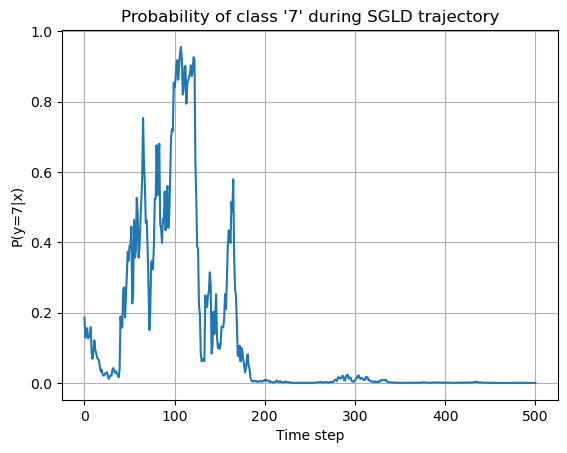

Best sample at step 107 with P(y=7|x) = 0.9557


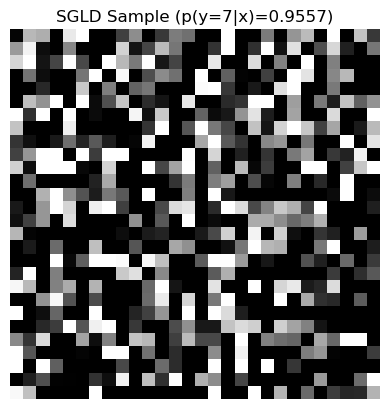

In [49]:
# Initial condition: random noise in normalized coordinates
x0 = torch.randn(1, dim, device=device)

# Run SGLD
n_steps = 500
t_grid, X = solver__1minusG.simulate(x0, n_steps=n_steps, return_trajectory=True)

# X has shape [n_steps+1, batch_size, dim] = [1001, 1, 784]
print(f"Trajectory shape: {X.shape}")

#  plot the probabilities during the trajectory
best_prob = 0.0
best_idx = -1
probs_during_trajectory = []
for i in range(X.shape[0]):
    x_img = X[i].view(1, 1, 28, 28)
    prob = get_seven_probability(model, x_img, device, normalize=False)
    if prob > best_prob:
        best_prob = prob
        best_idx = i
    probs_during_trajectory.append(prob)

#  plot
plt.plot(probs_during_trajectory)
plt.xlabel("Time step")
plt.ylabel("P(y=7|x)")
plt.title("Probability of class '7' during SGLD trajectory")
plt.grid()
plt.show()


x_final = X[best_idx]
print(f"Best sample at step {best_idx} with P(y=7|x) = {best_prob:.4f}")

# Reshape and denormalize for visualization
x_final_img = x_final.view(1, 1, 28, 28)
x_final_denorm = denormalize(x_final_img)

# Visualize
import matplotlib.pyplot as plt
plt.imshow(x_final_denorm.squeeze().cpu().numpy(), cmap='gray')
plt.title(f"SGLD Sample (p(y=7|x)={best_prob:.4f})")
plt.axis('off')
plt.show()